# Maze exploration

In [3]:
import pandas as pd
import tkinter as tk

# Monkey-patch the 'zoomed' state to 'normal'
tk.Tk.state = lambda self, s=None: self.wm_state('normal' if s == 'zoomed' else s)

In [5]:
df = pd.read_csv("data/maze.csv")

In [6]:
# Extract row and column indices from the 'cell' column
df[['row', 'col']] = (
df['  cell  '].astype(str).str.replace(r'[()]', '', regex=True).str.split(',', expand=True).astype(
        int))

In [7]:
df.head()

,cell,E,W,N,S,row,col
0,"(1, 1)",1,0,0,1,1,1
1,"(2, 1)",0,0,1,1,2,1
2,"(3, 1)",1,0,1,0,3,1
3,"(4, 1)",1,0,0,0,4,1
4,"(5, 1)",1,0,0,1,5,1


In [4]:
import csv

def generate_maze_csv(filename, rows=20, cols=20):
    """
    Generates a CSV file representing a 20x20 maze with 0 indicating no wall and 1 indicating a wall.
    Boundary cells have walls on the respective edges.
    """
    with open(filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        
        # Write the header row
        writer.writerow(["  cell  ", "E", "W", "N", "S"])
        
        # Loop over each cell in the grid
        for y in range(1, rows + 1):
            for x in range(1, cols + 1):
                # Determine boundary walls (1 for wall, 0 for no wall)
                E = 0 if x == cols else 1  # East boundary if at the last column
                W = 0 if x == 1 else 1     # West boundary if at the first column
                N = 0 if y == 1 else 1     # North boundary if at the first row
                S = 0 if y == rows else 1  # South boundary if at the last row
                
                # Each cell is labeled as (x, y)
                writer.writerow([f"({x},{y})", E, W, N, S])

# Generate the 20x20 maze CSV
generate_maze_csv("data/test_maze.csv")


In [5]:
from pyamaze import maze,agent
m=maze(20,20)
m.CreateMaze(loopPercent=50)
# a=agent(m,filled=True,footprints=True)
# m.tracePath({a:m.path})
# m.run()

In [43]:
from pyamaze import maze
import pandas as pd

def generate_df_maze(rows=20, cols=20):
    # Create a Pyamaze maze
    m = maze(rows, cols)
    m.CreateMaze(loopPercent=90)  # No loops to match a grid-like maze

    # List to store cell data
    maze_data = []

    # Loop through each cell in the maze
    for y in range(1, rows + 1):
        for x in range(1, cols + 1):
            cell = (x, y)
            cell_walls = m.maze_map[cell]  # Get wall info for each cell

            # Convert to E, W, N, S format (1 for wall, 0 for no wall)
            E = 1 if cell_walls['E'] else 0
            W = 1 if cell_walls['W'] else 0
            N = 1 if cell_walls['N'] else 0
            S = 1 if cell_walls['S'] else 0

            # Store cell information
            maze_data.append([f"({x},{y})", E, W, N, S])

    # Create DataFrame
    df = pd.DataFrame(maze_data, columns=["  cell  ", "E", "W", "N", "S"])
    return df

# Generate the maze DataFrame
df_maze = generate_df_maze(6, 6)
print(df_maze.head())


    cell    E  W  N  S
0    (1,1)  0  0  0  1
1    (2,1)  1  0  1  1
2    (3,1)  0  0  1  1
3    (4,1)  0  0  1  1
4    (5,1)  1  0  1  1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ast

def draw_maze_and_tasks(maze_csv, num_tasks, num_patrols):
    # Read the CSV file
    if type(maze_csv) == "str":
        df = pd.read_csv(maze_csv)
    else:
        df = maze_csv
    
    # Parse the cell string into a tuple and extract row, col
    df['  cell  '] = df['  cell  '].apply(lambda x: ast.literal_eval(x))
    df['row'] = df['  cell  '].apply(lambda t: t[0])
    df['col'] = df['  cell  '].apply(lambda t: t[1])
    
    # Create a plot for the maze
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # For each cell, draw walls where flagged (assume each cell spans from (col-1, row-1) to (col, row))
    for _, cell in df.iterrows():
        r, c = cell['row'], cell['col']
        # South wall: from (c-1, r-1) to (c, r-1)
        if cell['S'] == 0:
            ax.plot([c-1, c], [r-1, r-1], color='black')
        # North wall: from (c-1, r) to (c, r)
        if cell['N'] == 0:
            ax.plot([c-1, c], [r, r], color='black')
        # West wall: from (c-1, r-1) to (c-1, r)
        if cell['W'] == 0:
            ax.plot([c-1, c-1], [r-1, r], color='black')
        # East wall: from (c, r-1) to (c, r)
        if cell['E'] == 0:
            ax.plot([c, c], [r-1, r], color='black')
    
    # Set aspect ratio so cells appear square
    ax.set_aspect('equal')
    
    # # Sample a set of tasks from the maze cells and extract (row, col)
    # tasks_df = df[['row', 'col']].sample(n=num_tasks, random_state=47)
    # task_list = [ (int(t[0]), int(t[1])) for t in tasks_df.values.tolist() ]
    
    # # Cluster the tasks with KMeans
    # kmeans = KMeans(n_clusters=num_patrols, random_state=47).fit(task_list)
    # labels = kmeans.labels_
    
    # # Plot the tasks on top of the maze.
    # # We'll mark the center of each cell at (col - 0.5, row - 0.5)
    # xs = [t[1] - 0.5 for t in task_list]  # x comes from col
    # ys = [t[0] - 0.5 for t in task_list]  # y comes from row
    
    # scatter = ax.scatter(xs, ys, c=labels, cmap='tab10', s=100, edgecolors='k')
    
    # # Optionally, annotate each task with its cell coordinates.
    # for i, (x, y) in enumerate(zip(xs, ys)):
    #     ax.text(x, y, str(task_list[i]), color='white', ha='center', va='center')
    
    plt.title("Maze with Task Clusters")
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    # Optionally, invert y-axis if you want (e.g. so that (1,1) appears in the top-left)
    plt.gca().invert_yaxis()
    plt.show()

# Example usage:
# Assume your maze CSV is named 'maze.csv'
# draw_maze_and_tasks(df_maze, num_tasks=40, num_patrols=7)



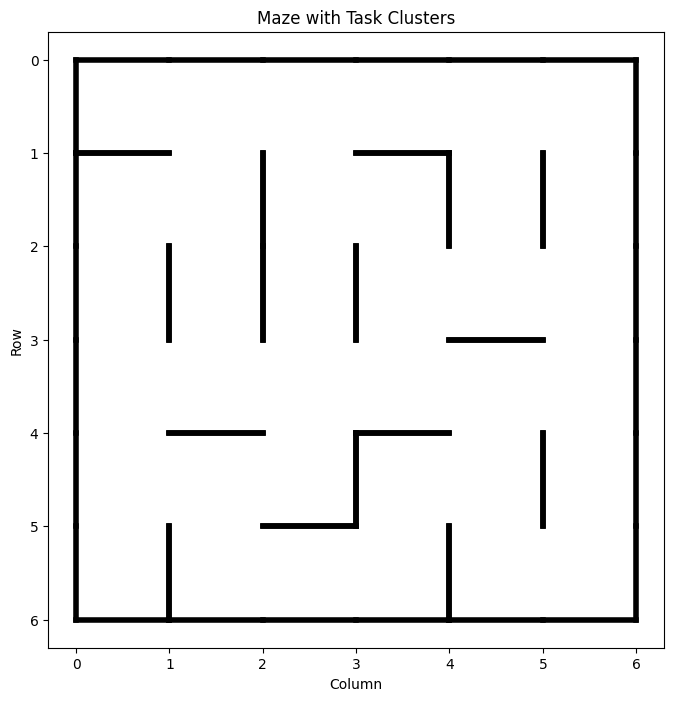

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ast

from pyamaze import maze
import pandas as pd

def generate_df_maze(rows=20, cols=20):
    # Create a Pyamaze maze
    m = maze(rows, cols)
    m.CreateMaze(loopPercent=90)  # No loops to match a grid-like maze

    # List to store cell data
    maze_data = []

    # Loop through each cell in the maze
    for y in range(1, rows + 1):
        for x in range(1, cols + 1):
            cell = (x, y)
            cell_walls = m.maze_map[cell]  # Get wall info for each cell

            # Convert to E, W, N, S format (1 for wall, 0 for no wall)
            E = 1 if cell_walls['E'] else 0
            W = 1 if cell_walls['W'] else 0
            N = 1 if cell_walls['N'] else 0
            S = 1 if cell_walls['S'] else 0

            # Store cell information
            maze_data.append([f"({x},{y})", E, W, N, S])

    # Create DataFrame
    df = pd.DataFrame(maze_data, columns=["  cell  ", "E", "W", "N", "S"])
    return df

# Generate the maze DataFrame
df_maze = generate_df_maze(6, 6)
# print(df_maze.head())


def draw_maze_and_tasks(maze_csv, num_tasks, num_patrols):
    # Read the CSV file
    if type(maze_csv) == "str":
        df = pd.read_csv(maze_csv)
    else:
        df = maze_csv
    
    # Parse the cell string into a tuple and extract row, col
    df['  cell  '] = df['  cell  '].apply(lambda x: ast.literal_eval(x))
    df['row'] = df['  cell  '].apply(lambda t: t[0])
    df['col'] = df['  cell  '].apply(lambda t: t[1])

    num_rows = int(df['row'].max())
    num_cols = int(df['col'].max())
    
    # Create a plot for the maze
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # For each cell, draw walls where flagged (assume each cell spans from (col-1, row-1) to (col, row))
    for _, cell in df.iterrows():
        r, c = cell['row'], cell['col']
        # South wall: from (c-1, r-1) to (c, r-1)
        if cell['S'] == 0:
            ax.plot([c-1, c], [num_rows-r,num_rows-r], color='black', linewidth=4)
        # North wall: from (c-1, r) to (c, r)
        if cell['N'] == 0:
            ax.plot([c-1, c], [num_rows-r+1, num_rows-r+1], color='black', linewidth=4)
        # West wall: from (c-1, r-1) to (c-1, r)
        if cell['W'] == 0:
            ax.plot([c-1, c-1], [num_rows-r+1,num_rows-r], color='black', linewidth=4)
        # East wall: from (c, r-1) to (c, r)
        if cell['E'] == 0:
            ax.plot([c, c], [num_rows-r, num_rows-r+1], color='black', linewidth=4)
    
    # Set aspect ratio so cells appear square
    ax.set_aspect('equal')
    
    plt.title("Maze with Task Clusters")
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    # Optionally, invert y-axis if you want (e.g. so that (1,1) appears in the top-left)
    plt.gca().invert_yaxis()
    plt.show()

draw_maze_and_tasks(df_maze, num_tasks=40, num_patrols=7)


# Streamlined testing

## Scenario 1

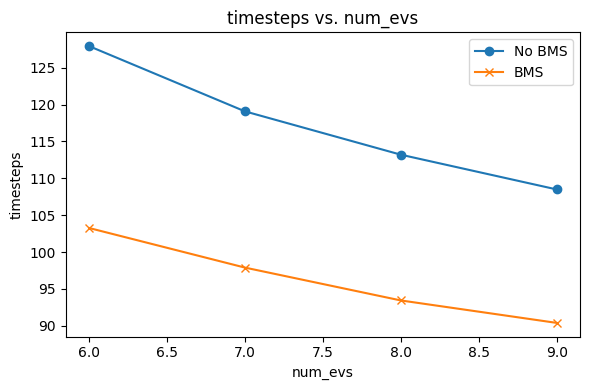

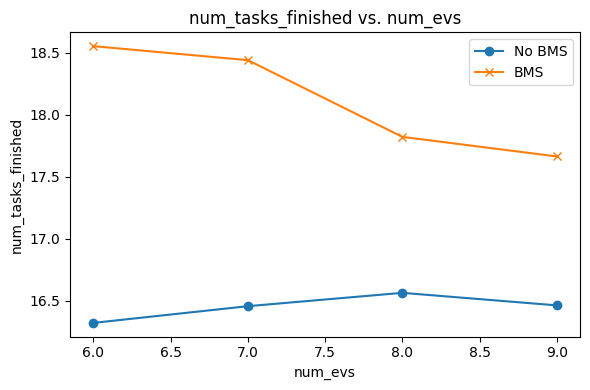

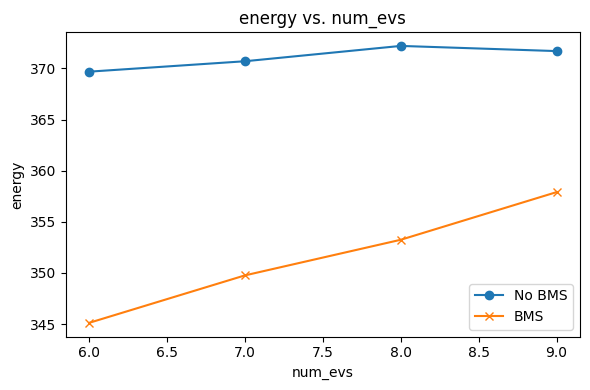

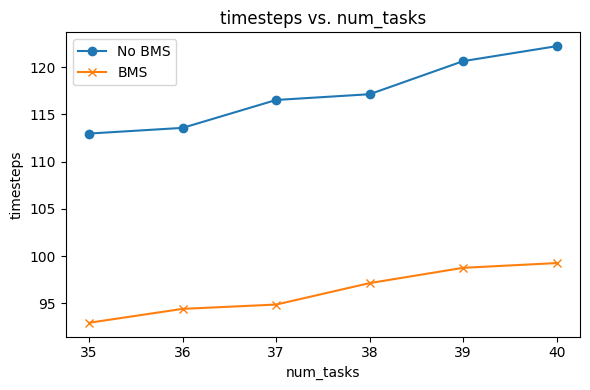

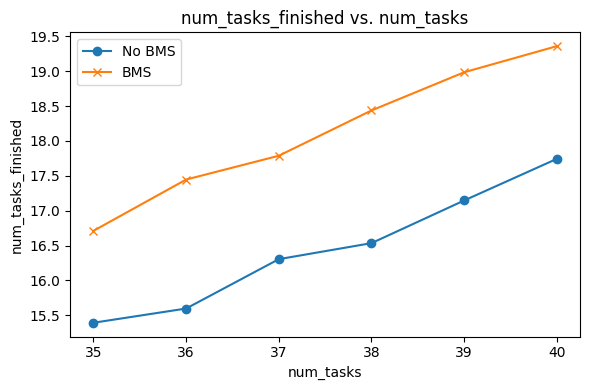

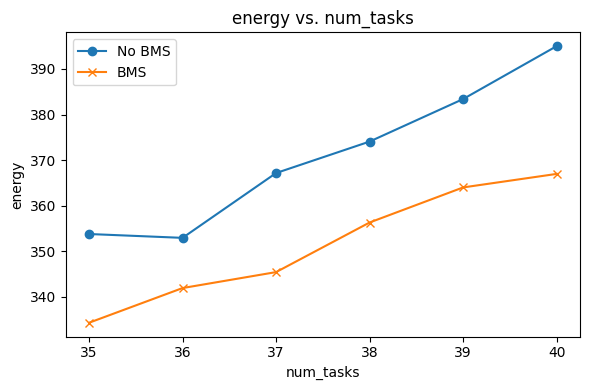

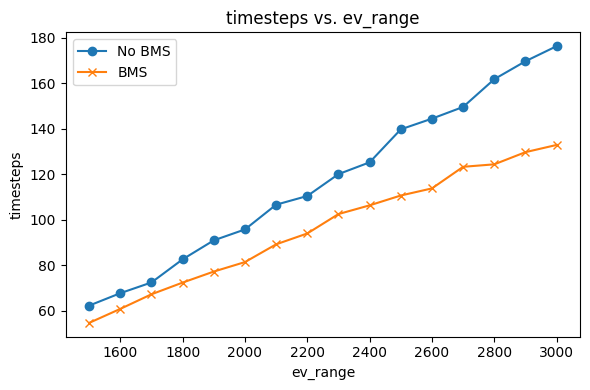

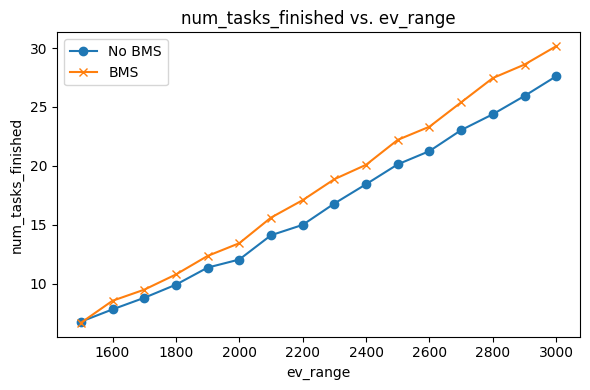

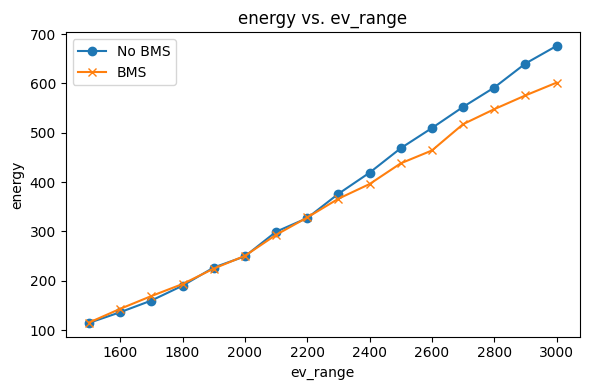

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your data
df = pd.read_csv("/home/shinobi-owl/PhD/battery/DroneSim/runs/scenario_1/results_2.csv")

# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.1*df['drone_distance']

# 2. Define the parameters to plot on the x-axis and the metrics (y-axis).
#    Here we choose three parameters and two metrics, yielding six plots total.
param_list = ['num_evs', 'num_tasks', 'ev_range']
metric_list = ['timesteps', 'num_tasks_finished', 'energy']

# 3. Loop over each parameter–metric pair to produce a separate plot
for param in param_list:
    for metric in metric_list:
        # Group the DataFrame by 'bms' and the chosen parameter, and take the average of the selected metric
        grouped = df.groupby(['bms', param], as_index=False)[metric].mean()
        
        # Split into No BMS (0) and BMS (1)
        df_no_bms = grouped[grouped['bms'] == 0]
        df_yes_bms = grouped[grouped['bms'] == 1]
        
        # 4. Create a figure for each plot
        plt.figure(figsize=(6,4))
        
        # Plot No BMS line
        plt.plot(df_no_bms[param], df_no_bms[metric], marker='o', label='No BMS')
        
        # Plot BMS line
        plt.plot(df_yes_bms[param], df_yes_bms[metric], marker='x', label='BMS')
        
        # 5. Label the axes and add a title/legend
        plt.xlabel(param)
        plt.ylabel(metric)
        plt.title(f'{metric} vs. {param}')
        plt.legend()
        plt.tight_layout()
        
        # 6. Show the plot (or save to file)
        plt.show()


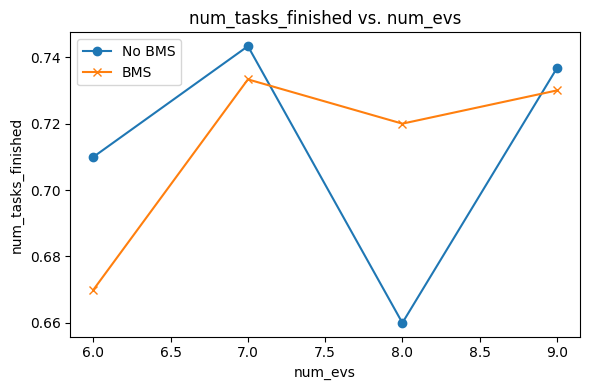

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your data
df = pd.read_csv("/home/shinobi-owl/PhD/battery/DroneSim/runs/scenario_1/results_3.csv")

df = df[df['ev_range']==500]
# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.1*df['drone_distance']

# 2. Define the parameters to plot on the x-axis and the metrics (y-axis).
#    Here we choose three parameters and two metrics, yielding six plots total.
param_list = ['num_evs', ]
metric_list = ['num_tasks_finished']

# 3. Loop over each parameter–metric pair to produce a separate plot
for param in param_list:
    for metric in metric_list:
        # Group the DataFrame by 'bms' and the chosen parameter, and take the average of the selected metric
        grouped = df.groupby(['bms', param], as_index=False)[metric].mean()
        
        # Split into No BMS (0) and BMS (1)
        df_no_bms = grouped[grouped['bms'] == 0]
        df_yes_bms = grouped[grouped['bms'] == 1]
        
        # 4. Create a figure for each plot
        plt.figure(figsize=(6,4))
        
        # Plot No BMS line
        plt.plot(df_no_bms[param], df_no_bms[metric], marker='o', label='No BMS')
        
        # Plot BMS line
        plt.plot(df_yes_bms[param], df_yes_bms[metric], marker='x', label='BMS')
        
        # 5. Label the axes and add a title/legend
        plt.xlabel(param)
        plt.ylabel(metric)
        plt.title(f'{metric} vs. {param}')
        plt.legend()
        plt.tight_layout()
        
        # 6. Show the plot (or save to file)
        plt.show()


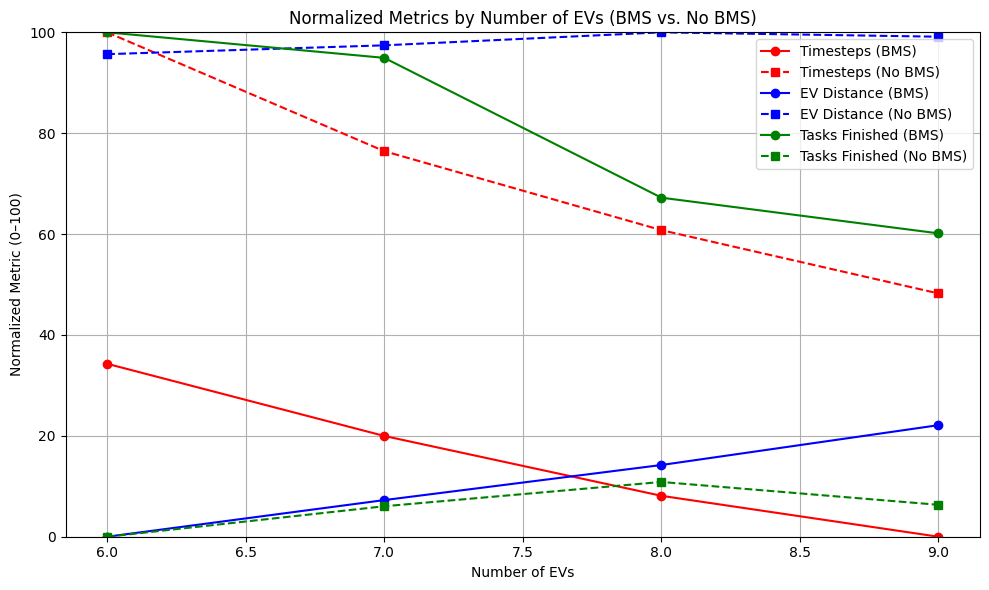

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data
df = pd.read_csv("runs/scenario_1/results_2.csv")

# 1) Group by num_evs and bms, compute mean of key metrics
group = df.groupby(['num_evs', 'bms'], as_index=False).mean(
    numeric_only=True
)[['num_evs', 'bms', 'timesteps', 'ev_distance', 'num_tasks_finished']]

# 2) For convenience, define the metrics we want to normalize and plot
metrics = {
    'timesteps': 'Timesteps',
    'ev_distance': 'EV Distance',
    'num_tasks_finished': 'Tasks Finished'
}

# 3) Compute overall min and max for each metric (across both BMS and no-BMS)
#    so everything is on a single 0–100 scale for easier comparison.
for m in metrics.keys():
    col_min = group[m].min()
    col_max = group[m].max()
    # Normalize: (value - min) / (max - min) * 100
    group[m + '_norm'] = (group[m] - col_min) / (col_max - col_min) * 100 if col_max != col_min else 50

# 4) Separate the grouped data back into BMS and no-BMS
group_bms = group[group['bms'] == 1]
group_no_bms = group[group['bms'] == 0]

# 5) Plot all three metrics in one figure
fig, ax = plt.subplots(figsize=(10, 6))

# Choose colors for each metric (optional)
colors = {
    'timesteps': 'red',
    'ev_distance': 'blue',
    'num_tasks_finished': 'green'
}

for m in metrics.keys():
    m_norm = m + '_norm'
    label_bms = f"{metrics[m]} (BMS)"
    label_no_bms = f"{metrics[m]} (No BMS)"
    
    # Plot the BMS line (solid)
    ax.plot(group_bms['num_evs'], group_bms[m_norm],
            color=colors[m], marker='o', linestyle='-',
            label=label_bms)
    
    # Plot the no-BMS line (dashed)
    ax.plot(group_no_bms['num_evs'], group_no_bms[m_norm],
            color=colors[m], marker='s', linestyle='--',
            label=label_no_bms)

# 6) Format and display
ax.set_xlabel('Number of EVs')
ax.set_ylabel('Normalized Metric (0–100)')
ax.set_ylim(0, 100)  # Ensure the y-axis spans 0 to 100
ax.set_title('Normalized Metrics by Number of EVs (BMS vs. No BMS)')
ax.grid(True)
ax.legend(loc='best')

plt.tight_layout()
plt.show()


## Scenario 2

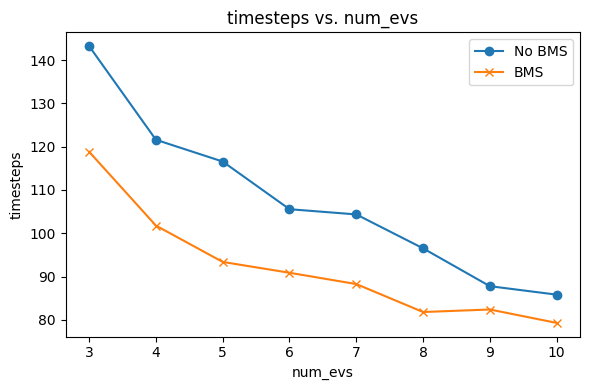

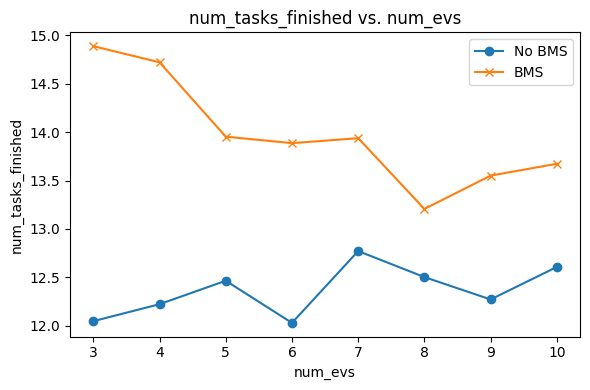

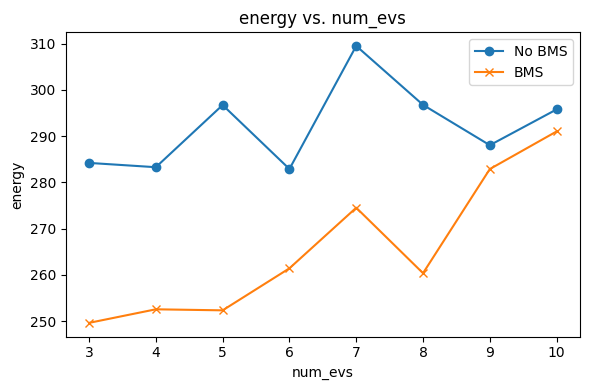

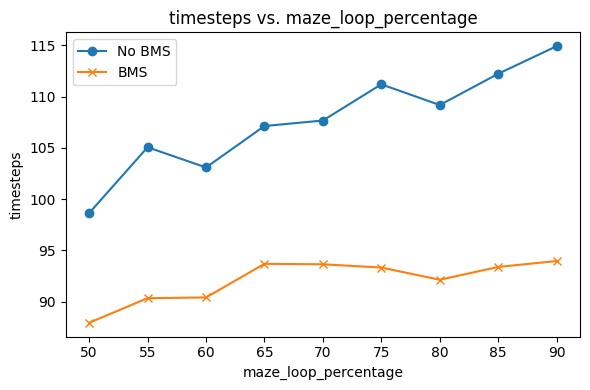

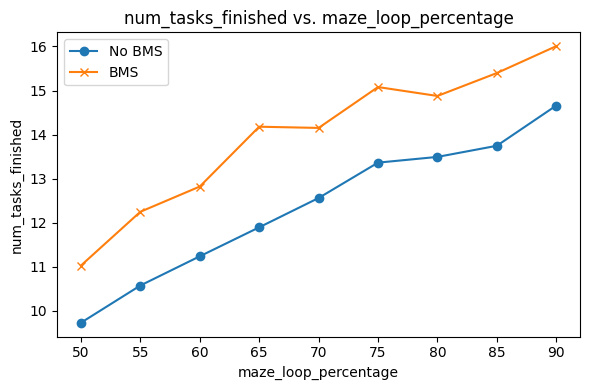

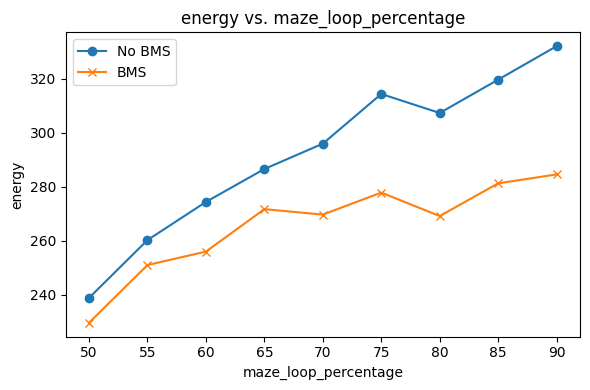

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your data
df = pd.read_csv("/home/shinobi-owl/PhD/battery/DroneSim/runs/scenario_2/results_ev.csv")

# (Optional) Compute an 'energy' column if you also want to plot energy consumption.
df['energy'] = df['ev_distance'] + 0.01*df['drone_distance']

# 2. Define the parameters to plot on the x-axis and the metrics (y-axis).
#    Here we choose three parameters and two metrics, yielding six plots total.
param_list = ['num_evs', 'maze_loop_percentage']
metric_list = ['timesteps', 'num_tasks_finished', 'energy']

# 3. Loop over each parameter–metric pair to produce a separate plot
for param in param_list:
    for metric in metric_list:
        # Group the DataFrame by 'bms' and the chosen parameter, and take the average of the selected metric
        grouped = df.groupby(['bms', param], as_index=False)[metric].mean()
        
        # Split into No BMS (0) and BMS (1)
        df_no_bms = grouped[grouped['bms'] == 0]
        df_yes_bms = grouped[grouped['bms'] == 1]
        
        # 4. Create a figure for each plot
        plt.figure(figsize=(6,4))
        
        # Plot No BMS line
        plt.plot(df_no_bms[param], df_no_bms[metric], marker='o', label='No BMS')
        
        # Plot BMS line
        plt.plot(df_yes_bms[param], df_yes_bms[metric], marker='x', label='BMS')
        
        # 5. Label the axes and add a title/legend
        plt.xlabel(param)
        plt.ylabel(metric)
        plt.title(f'{metric} vs. {param}')
        plt.legend()
        plt.tight_layout()
        
        # 6. Show the plot (or save to file)
        plt.show()
